In [3]:
import numpy as np

names = ['A','B','C','D','E','F','G','H','I']
subjects = ['Math','Science','English']

marks_2d = np.array([ [85,80,88],[90,85,92],[78,72,75],[92,88,90],[67,70,65], [88,83,86],[74,78,80],[81,76,79],[95,91,93] ])

# Total per student - List comprehension
total = [marks_2d[i].sum() for i in range(len(names))]
[print(f'{n}: {t}') for n, t in zip(names, total)]

# Average per subject - List comprehension
avg = [round(marks_2d[:, j].mean(), 2) for j in range(3)]
[print(f'{s}: {a}') for s, a in zip(subjects, avg)]

# Highest scorer
print(f'Top student: {names[np.argmax(total)]} ({max(total)} marks)')


A: 253
B: 267
C: 225
D: 270
E: 202
F: 257
G: 232
H: 236
I: 279
Math: 83.33
Science: 80.33
English: 83.11
Top student: I (279 marks)


In [4]:
import numpy as np

np.random.seed(42)
numbers = np.random.randint(-30, 100, 20)

above_50 = [int(x) for x in numbers if x > 50]
even_nums = [int(x) for x in numbers if x % 2 == 0]
no_negative = [int(x) if x >= 0 else 0 for x in numbers]

print('Values > 50 :', above_50)
print('Even numbers :', even_nums)
print('Negatives > 0 :', no_negative)

Values > 50 : [72, 62, 76, 72, 91, 57, 86, 69, 73, 57, 99]
Even numbers : [72, 62, -16, 76, -10, 72, 44, 86, 22, -10]
Negatives > 0 : [72, 62, 0, 76, 41, 0, 72, 91, 44, 57, 86, 69, 73, 22, 0, 57, 7, 99, 0, 27]


In [5]:
import pandas as pd

df = pd.DataFrame({
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'Marks': [85, 62, 91, 45, 78, 55, 88],
    'City': ['City1', 'City2', 'City2', 'City3', 'City4', 'City5', 'City6']
})

# Filter marks > 70
above_70 = df[df['Marks'] > 70]

# Sort by marks (descending)
sorted_df = df.sort_values('Marks', ascending=False)

# Add grade column
def assign_grade(m):
    if m >= 90: return 'A+'
    elif m >= 80: return 'A'
    elif m >= 70: return 'B'
    elif m >= 60: return 'C'
    else: return 'D'

df['Grade'] = df['Marks'].apply(assign_grade)
print(df)

  Name  Marks   City Grade
0    A     85  City1     A
1    B     62  City2     C
2    C     91  City2    A+
3    D     45  City3     D
4    E     78  City4     B
5    F     55  City5     D
6    G     88  City6     A


In [6]:
import pandas as pd

df_emp = pd.DataFrame({
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'Department': ['IT', 'HR', 'IT', 'Finance', 'HR', 'Finance', 'IT'],
    'Salary': [75000, 50000, 90000, 65000, 48000, 70000, 80000]
})

avg_sal = df_emp.groupby('Department')['Salary'].mean()

# Highest paid employee
top = df_emp.loc[df_emp['Salary'].idxmax()]
print(f'Highest paid: {top["Name"]} - {top["Salary"]}')

# Count per department
count = df_emp.groupby('Department')['Name'].count()
print(count)

Highest paid: C - 90000
Department
Finance    2
HR         2
IT         3
Name: Name, dtype: int64


In [8]:
import pandas as pd

df = pd.read_csv("data.csv")

print("Original Data:")
print(df)

print("\nMissing Values per Column:")
print(df.isnull().sum())

df_filled = df.fillna(df.mean(numeric_only=True))
print("\nData after filling missing values:")
print(df_filled)

df_dropped = df.dropna()
print("\nData after dropping missing rows:")
print(df_dropped)

Original Data:
  Name   Age  Salary  Marks
0    A    25   50000     85
1    B    30   60000     90
2    C    35   70000    NaN
3    D    40   80000     95
4    E    45     NaN     88

Missing Values per Column:
Name       0
 Age       0
 Salary    0
 Marks     0
dtype: int64

Data after filling missing values:
  Name   Age  Salary  Marks
0    A    25   50000     85
1    B    30   60000     90
2    C    35   70000    NaN
3    D    40   80000     95
4    E    45     NaN     88

Data after dropping missing rows:
  Name   Age  Salary  Marks
0    A    25   50000     85
1    B    30   60000     90
2    C    35   70000    NaN
3    D    40   80000     95
4    E    45     NaN     88


In [12]:
import pandas as pd

df = pd.read_csv("data2.csv")
df.columns = df.columns.str.strip()

print("Top 5 Rows:")
print(df.head())

print("\nUnique Values in Category:")
print(df['Category'].unique())

print("\nGrouped Data (Category-wise Count):")
print(df.groupby('Category').size())

Top 5 Rows:
  Name      Category          City  Sales
0    A   Electronics      New York   1000
1    B      Clothing   Los Angeles   1500
2    C   Electronics       Chicago   2000
3    D      Clothing       Houston   1200
4    E   Electronics       Phoenix   1800

Unique Values in Category:
[' Electronics' ' Clothing' ' Grocery']

Grouped Data (Category-wise Count):
Category
Clothing       3
Electronics    4
Grocery        3
dtype: int64


In [13]:
import pandas as pd

data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'City': ['Mumbai', 'Pune', 'Nagpur', 'Mumbai', 'Pune', 'Nagpur', 'Mumbai'],
    'Salary': [75000, 55000, 45000, 85000, 60000, 48000, 90000],
    'Age': [22, 24, 23, 25, 22, 26, 24]
}
df = pd.DataFrame(data)

result = df.groupby('City').agg({
    'Salary': 'mean',
    'Name': 'count'
})
result.rename(columns={'Salary': 'Average Income', 'Name': 'Total Population'}, inplace=True)
print(result)

        Average Income  Total Population
City                                    
Mumbai    83333.333333                 3
Nagpur    46500.000000                 2
Pune      57500.000000                 2


In [14]:
import pandas as pd

students = {
    'ID': [1, 2, 3, 4],
    'Name': ['A', 'B', 'C', 'D']
}
df_students = pd.DataFrame(students)

marks = {
    'ID': [1, 2, 3, 4],
    'Marks': [88, 76, 91, 65]
}
df_marks = pd.DataFrame(marks)

merged = pd.merge(df_students, df_marks, on='ID')
print(merged)

   ID Name  Marks
0   1    A     88
1   2    B     76
2   3    C     91
3   4    D     65


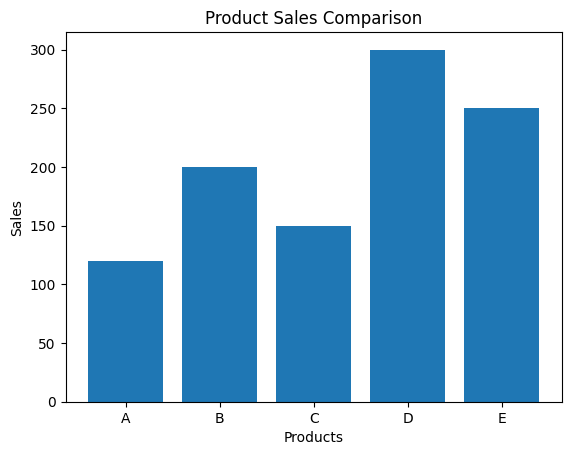

Highest Selling Product: D


In [15]:
import matplotlib.pyplot as plt

products = ['A', 'B', 'C', 'D', 'E']
sales = [120, 200, 150, 300, 250]

plt.bar(products, sales)
plt.title("Product Sales Comparison")
plt.xlabel("Products")
plt.ylabel("Sales")
plt.show()

max_sales = max(sales)
index = sales.index(max_sales)
print("Highest Selling Product:", products[index])

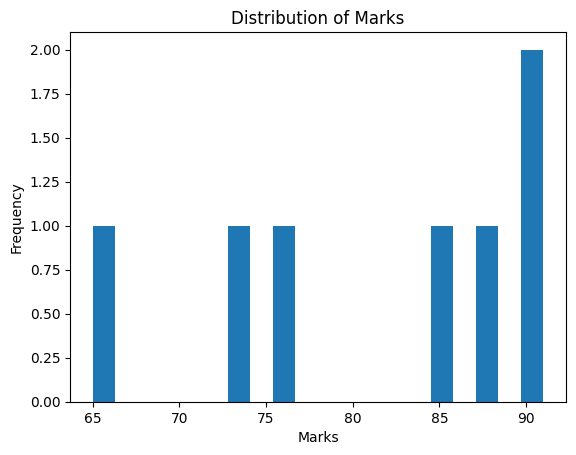

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'City': ['Mumbai', 'Pune', 'Nagpur', 'Mumbai', 'Pune', 'Nagpur', 'Mumbai'],
    'Salary': [75000, 55000, 45000, 85000, 60000, 48000, 90000],
    'Age': [22, 24, 23, 25, 22, 26, 24],
    'Marks': [88, 76, 91, 65, 73, 85, 90]
}
df = pd.DataFrame(data)

plt.hist(df['Marks'], bins=20)
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()


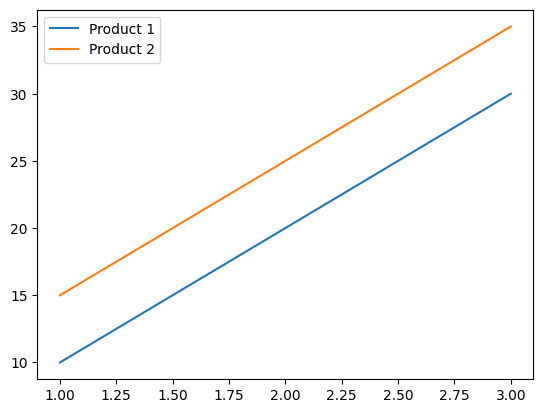

In [17]:
import matplotlib.pyplot as plt

x = [1, 2, 3]
product1 = [10, 20, 30]
product2 = [15, 25, 35]

plt.plot(x, product1, label="Product 1")
plt.plot(x, product2, label="Product 2")
plt.legend()
plt.show()

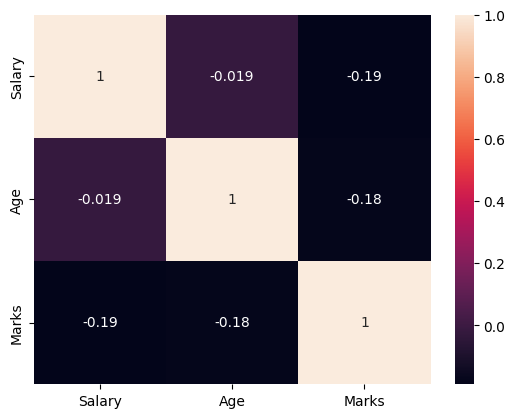

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'City': ['Mumbai', 'Pune', 'Nagpur', 'Mumbai', 'Pune', 'Nagpur', 'Mumbai'],
    'Salary': [75000, 55000, 45000, 85000, 60000, 48000, 90000],
    'Age': [22, 24, 23, 25, 22, 26, 24],
    'Marks': [88, 76, 91, 65, 73, 85, 90]
}
df = pd.DataFrame(data)

corr = df[['Salary', 'Age', 'Marks']].corr()
sns.heatmap(corr, annot=True)
plt.show()

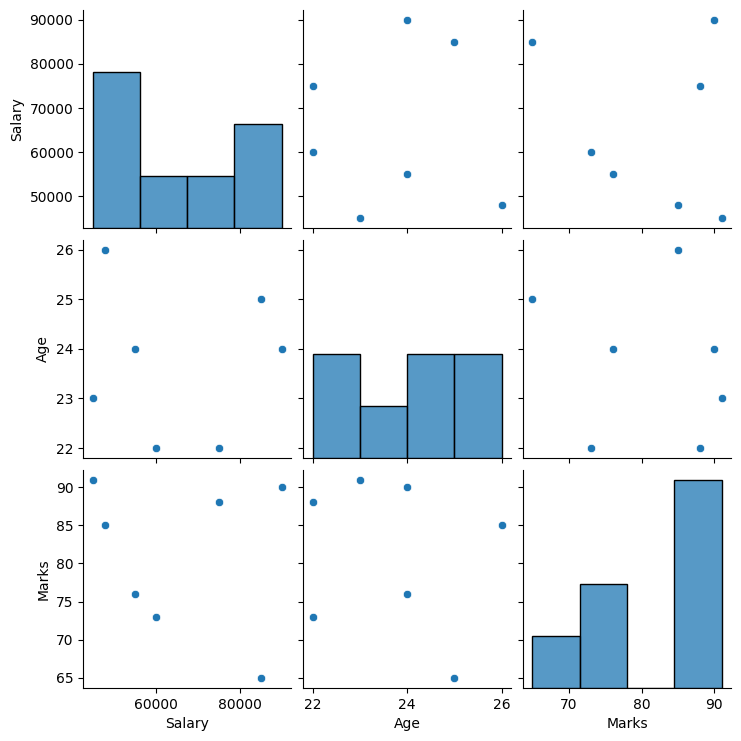

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'City': ['Mumbai', 'Pune', 'Nagpur', 'Mumbai', 'Pune', 'Nagpur', 'Mumbai'],
    'Salary': [75000, 55000, 45000, 85000, 60000, 48000, 90000],
    'Age': [22, 24, 23, 25, 22, 26, 24],
    'Marks': [88, 76, 91, 65, 73, 85, 90]
}
df = pd.DataFrame(data)

sns.pairplot(df)
plt.show()

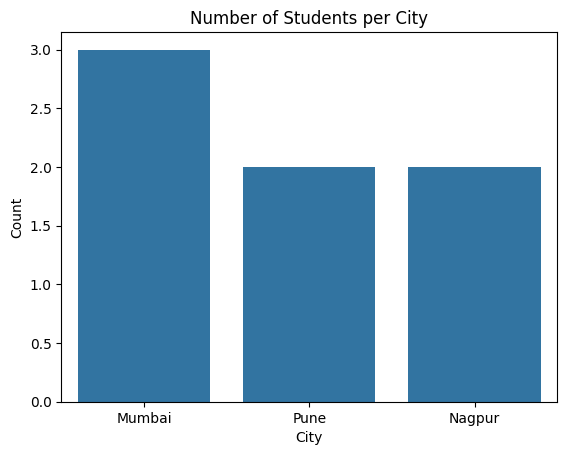

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Name': ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    'City': ['Mumbai', 'Pune', 'Nagpur', 'Mumbai', 'Pune', 'Nagpur', 'Mumbai'],
    'Salary': [75000, 55000, 45000, 85000, 60000, 48000, 90000],
    'Age': [22, 24, 23, 25, 22, 26, 24],
    'Marks': [88, 76, 91, 65, 73, 85, 90]
}
df = pd.DataFrame(data)

sns.countplot(x='City', data=df)
plt.title("Number of Students per City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

In [2]:
def get_student_marks():
    marks_list = []
    
    for i in range(5):
        while True:
            try:
                marks = input(f"Enter marks for student {i+1}: ")
                marks = float(marks)
                
                if marks < 0 or marks > 100:
                    raise ValueError("Marks must be between 0 and 100")
                
                marks_list.append(marks)
                break
                
            except ValueError as e:
                print(f"Error: {e}")
            except Exception as e:
                print(f"Unexpected error: {e}")
            else:
                print("Valid marks entered!")
            finally:
                print("Processing next student...")
    
    print(f"\nFinal valid marks list: {marks_list}")
    return marks_list

get_student_marks()

Error: Marks must be between 0 and 100
Processing next student...
Processing next student...
Processing next student...
Error: Marks must be between 0 and 100
Processing next student...
Processing next student...
Processing next student...
Error: Marks must be between 0 and 100
Processing next student...
Error: Marks must be between 0 and 100
Processing next student...
Error: Marks must be between 0 and 100
Processing next student...
Processing next student...

Final valid marks list: [42.0, 53.0, 43.0, 53.0, 90.0]


[42.0, 53.0, 43.0, 53.0, 90.0]

In [3]:
class InvalidMenuChoiceError(Exception):
    pass

def calculator():
    print("\n--- Calculator Menu ---")
    print("1. Addition")
    print("2. Subtraction")
    print("3. Multiplication")
    print("4. Division")
    
    try:
        choice = input("Enter your choice (1-4): ")
        choice = int(choice)
        
        if choice not in [1, 2, 3, 4]:
            raise InvalidMenuChoiceError("Invalid menu choice! Please select 1-4.")
        
        try:
            num1 = float(input("Enter first number: "))
            num2 = float(input("Enter second number: "))
        except ValueError:
            print("Error: Invalid input! Please enter numeric values.")
            return
        
        if choice == 1:
            result = num1 + num2
            print(f"Result: {num1} + {num2} = {result}")
        elif choice == 2:
            result = num1 - num2
            print(f"Result: {num1} - {num2} = {result}")
        elif choice == 3:
            result = num1 * num2
            print(f"Result: {num1} × {num2} = {result}")
        elif choice == 4:
            try:
                result = num1 / num2
                print(f"Result: {num1} ÷ {num2} = {result}")
            except ZeroDivisionError:
                print("Error: Division by zero is not allowed!")
                
    except InvalidMenuChoiceError as e:
        print(f"Error: {e}")
    except ValueError:
        print("Error: Invalid menu choice! Please enter a number.")
    finally:
        print("Calculator operation completed.")

calculator()


--- Calculator Menu ---
1. Addition
2. Subtraction
3. Multiplication
4. Division
Error: Invalid menu choice! Please select 1-4.
Calculator operation completed.
